# Realistic use of ZTF  

Here we show how to use `skysurvey` to simulate a ZTF DR2-like sample of Type Ia Supernovae. We reproduce the ZTF DR2 observing logs and apply its selection effects to a simulated population of SNe Ia, then compare the redshift distributions of the simulated and observed samples.

***

We first load the logs from the ZTF survey for the DR2:

In [ ]:
import skysurvey

# load the ZTF logs
ztf = skysurvey.ZTF.from_logs()

We then apply the correction coefficients on the g,r and i ZTF filters (from [sncosmo](https://sncosmo.readthedocs.io/en/stable/bandpass-list.html)) determined in the DR2 release papers (Rigault et al.(2025b) (2025A&A...694A...2R) and Amenouche et al.(2025) (2025A&A...694A...3A)). The original sky noise is stored in `skynoise_orig` and the corrected values (scaled per each bands with the corresponding factors) are stored back into `skynoise`.

In [2]:
import pandas

# apply the Rigault+2025(LC) / Amenouche+2025 correction
coefs = {"ztfg": 1.23, 
         "ztfr":1.17, 
         "ztfi": 1.2}

ztf.data["skynoise_orig"] = ztf.data["skynoise"].copy()
s = ztf.data.groupby("band", group_keys=True)["skynoise_orig"]
skynoise = pandas.concat([s.get_group(f_)*coefs[f_] for f_ in coefs.keys()])
ztf.data["skynoise"] = skynoise

The dataframe now contains both `skynoise_orig` and `skynoise`:

In [3]:
ztf.data

,mjd,band,fieldid,fieldra,fielddec,rcid,maglimit,zp,gain,expid,infobits,skynoise,skynoise_orig
0,58288.171875,ztfi,375,3.787257,-0.171915,16,19.650887,25.644886,6.2,53417042,0,59.953015,49.960846
1,58288.171875,ztfi,375,3.787257,-0.171915,17,19.612961,25.651960,6.2,53417042,0,62.490079,52.075066
2,58288.171875,ztfi,375,3.787257,-0.171915,18,19.686562,25.683561,6.2,53417042,0,60.118913,50.099094
3,58288.171875,ztfi,375,3.787257,-0.171915,19,19.632156,25.650158,6.2,53417042,0,61.293141,51.077618
4,58288.171875,ztfi,375,3.787257,-0.171915,20,19.573307,25.693308,6.2,53417042,0,67.330458,56.108715
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32808490,59273.558594,ztfr,542,5.338955,0.205076,43,17.924723,26.281721,6.1,151955745,33554440,515.246712,440.381805
32808491,59273.558594,ztfr,542,5.338955,0.205076,44,18.117277,26.246277,6.1,151955745,0,417.653116,356.968475
32808492,59273.558594,ztfr,542,5.338955,0.205076,45,18.143761,26.199760,6.1,151955745,33554432,390.495248,333.756622
32808493,59273.558594,ztfr,542,5.338955,0.205076,46,18.018276,26.206276,6.2,151955745,33554440,440.976813,376.903259


We then import the Milky Way dustmaps, the SFD (Schlegel, Finkbeiner & Davis (1998)), used for the ZTF survey:

In [ ]:
import dustmaps.sfd
dustmaps.sfd.fetch()

And simulate SN Ia, including the MW extinction, from the beginning to the end of the ZTF DR2, at the maximum redshift observed.

In [5]:
# load SN Ia data as given by nature
snia = skysurvey.SNeIa.from_draw(tstart="2018-03-01", tstop="2020-12-21", 
                                 zmax=0.18,
                                 effect=skysurvey.Effect.from_name('mw'), 
                                 mwebv=  {"which":"sfd"} # forces map used in ZTF
                                )


We simulate them with the constant following SNe Ia rate, derived from Perley et al.(2020) (2020ApJ...904...35P):

In [6]:
snia.rate

23500.0

A redshift-dependant rate can also be used (see "Change the rate of a target). 
This gives us, in this example, a sample of 122 861 SNe Ia:

In [7]:
len(snia.data)

122861

With the targets, and the survey, we can obtain the dataset by generating the SNe Ia lightcurves:

In [8]:
# Generate the LC
dset = skysurvey.DataSet.from_targets_and_survey(snia, ztf, progress_bar=True)

100%|██████████| 90855/90855 [12:38<00:00, 119.80it/s] 


Not all the 122 866 simulated SNe Ia will have a light curve generated. `from_targets_and_survey` first performs a geometric match between each SN's sky position and the ZTF observed fields. SNe Ia that fall outside the ZTF footprint during are simply never observed and are excluded from the dataset. That is why ~25% SNe Ia are lost to sky coverage, so that the sample has now 90 855 SNe Ia with associated light curves.

Moreover, not all the light curves here are relevant for cosmological analyses. We apply the "good sampling" light curve quality cuts determined in Rigault et al.(2025b) and Rigault et al.(2025a) (2025A&A...694A...1R) for the ZTF DR2, which, among other things, define 
the phase range over which SALT2 fits are well constrained for ZTF DR2: 

- **Full range**:
    - within the −10 to +40 days rest-frame phase range
    - at least seven 5σ flux detections
    - in at least 2 bands 
    - same-night same-band detections are ignored, such that, for example, four detections on the same night in g only account for 1 phase
- **Pre-max**:
    - at least two 5σ flux detections
    - in at least 2 bands 
- **Post-max**:
    - at least two 5σ flux detections
    - in at least 2 bands 

And apply them to our sample:

In [9]:
# Apply the DR2 LC "good sampling" cuts
# full range
data = dset.get_ndetection(phase_range=[-10, 40], per_band=True, join_bandday=True)
minfilters = data.groupby(level=0).size()>= 2
ndetect = data.groupby(level=(0)).sum() >= 7
ok = (minfilters & ndetect)
print(ok.mean())

# pre-max
data = dset.get_ndetection(phase_range=[-10, 0], per_band=True, join_bandday=True)
minfilters = data.groupby(level=0).size()>= 2
ndetect = data.groupby(level=(0)).sum() >= 2
ok = ok & minfilters & ndetect
print(ok.mean())

# post-max
data = dset.get_ndetection(phase_range=[0, 40], per_band=True, join_bandday=True)
minfilters = data.groupby(level=0).size()>= 2
ndetect = data.groupby(level=(0)).sum() >= 2
ok = ok & minfilters & ndetect
print(ok.mean())
print(f"we are left with: {len(ok[ok])/len(snia.data)} Type Ia Supernovae.") 

index_goodlc = ok[ok].index

0.5590596467684344
0.4558700184523952
0.4306118047401088
we are left with: 0.14625471060792278 Type Ia Supernovae.


`get_ndetection` only returns SNe Ia with at least one detection in the requested phase range, so the fractions are computed over the detected subsample. Of the SNe Ia with generated light curves and at least one detection:
- ~55% of them pass the cuts on the full range
- ~45% of them pass the cuts on the pre-max
- ~43% of them pass the cuts on the post-max

Ultimately, roughly 14% (~17 201) SNe Ia of the original sample pass all the cuts. 

Spectroscopic typing is required to confirm a transient as a Type Ia Supernova. In ZTF, this relies on spectra from the SED Machine (SEDM), whose limiting magnitude (~18.5) is another selection effect on the sample. We model this spectroscopic selection (hereafter spectroscopic completeness) as a survival sigmoid function of the SN Ia's observed peak magnitude:


$$P_\text{spec}(m) = 1 - \mathcal{S}(m;\, m_0, s) = \frac{1}{1 + e^{s(m - m_0)}}$$

where $m_0$ is the magnitude threshold and $s$ controls the steepness of the  drop-off (see Fig. 5 of Rigault et al. 2025a).

This function defines the probability that a photometrically detected SN Ia was actually targeted for spectroscopic follow-up. (see Rigault et al.(2025a))

In [10]:
import numpy as np
from scipy.special import expit 

def get_spectro_completeness(mag, loc=18.8, scale=4.5): 
    """ Survival sigmoid function.
    
    1- scipy.special.expit( (mag -loc)*scale)
    """
    mag = np.atleast_1d(mag)
    return 1-expit( (mag-loc) * scale)

We start from the simulated SNe Ia that passed the light curve quality cuts.

In [11]:
# get data of SNe Ia with good sampling
data_good_lc = snia.data.loc[index_goodlc].copy()

In addition to the magnitude-dependent spectroscopic completeness, ZTF did not systematically obtain spectra for transients behind the Milky Way plane, where dust extinction is too high. We remove simulated SNe Ia with $A_V = R_V \times  E(B-V) \geq 1$, with $A_V = 3.5$.

In [12]:
# remove case that were not followed for spectroscopy because of MW
data_used = data_good_lc[(data_good_lc["mwebv"] * 3.1 < 1)].copy()

And so, for all the SNe Ia that have a good light curve, we compute the probability of receiving spectroscopic follow-up based on their observed peak magnitude, using the `get_spectro_completeness` function. Note that slightly different parameters ($m_0 = 18.55$, $s = 3.8$) are used here, reflecting a refined calibration for this analysis.

In [13]:
# measure the probability to get a spectrum for this target.
data_used["pobs_spec"] = get_spectro_completeness(data_used["magobs"], loc=18.55 , scale=3.8)

Now that each simulated SN Ia has an associated spectroscopic probability $P_\text{spec}$, we want to transfom the simulated sample into the sample we should've observed. We bin the sample in narrow redshift shells ($\Delta z = 0.01$) and compute 
the mean spectroscopic probability $\langle P_\text{spec} \rangle$ per shell. Within each shell, the magnitude distribution is approximately uniform, so the mean spectroscopic probability $f_\text{obs} = \langle P_\text{spec} \rangle$  correctly reflects the completeness at that distance.

In [14]:
# Bin per redshift and measure the fraction of SNe Ia that get a spectrum per bin.
zbins = np.arange(0, data_used["z"].max(), step=0.01)
data_used["zbins"] = pandas.cut(data_used["z"], zbins)
pobs = data_used.groupby("zbins", observed=False)["pobs_spec"].mean()

Working bin by bin of redshift is important because at low redshift ($z \lesssim 0.06$, the volume-limited sample for the ZTF DR2, determined in Rigault et al.(2025a) and Amenouche et al.(2025)), SNe Ia peak between magnitudes 15 and 18.5 (see Figure 5 in Rigault et al.(2025a)), so $f_\text{obs} \approx 1$. At higher redshift, SNe Ia become fainter on average and $f_\text{obs}$  drops accordingly, as show in the figure below.

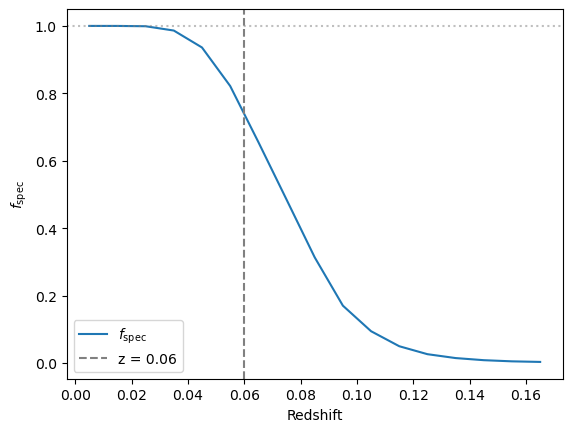

In [15]:
import matplotlib.pyplot as plt

pobs_numeric = pobs.copy()
pobs_numeric.index = pobs.index.map(lambda x: x.mid)

fig, ax = plt.subplots()
ax.plot(pobs_numeric.index, pobs_numeric.values, label=r"$f_\text{spec}$")
ax.axvline(0.06, color="gray", ls="--", label="z = 0.06")
ax.axhline(1.0, color="gray", ls=":", alpha=0.5)
ax.set_xlabel("Redshift")
ax.set_ylabel(r"$f_\text{spec}$")
ax.legend()

For each shell, a fraction $f_\text{obs} $ of SNe Ia is drawn, weighted by their individual $P_\text{spec}$ ( SNe with higher spectroscopic probability are preferentially selected).

In [16]:
# Loop over the redshift bin and get a fraction of the sample 
# corresponding to the fraction SN Ia that have a spectrum in that bin
data_obs = []
for zbin in pobs.index:
    data_of_zbin = data_used[data_used["zbins"] == zbin]
    fobs = data_of_zbin["pobs_spec"].mean()
    data_obs.append(data_of_zbin.sample(frac=fobs, weights="pobs_spec", replace=False))

The retained SNe Ia from all shells are then concatenated into the final sample `data_obs`, the number of SNe Ia we expect to observe.

In [17]:
# join this redshift binned data back together
data_obs = pandas.concat(data_obs)

In [18]:
print(f"We expect {len(data_obs)} well sampled Type Ia Supernovae.")

We expect 2815 well sampled Type Ia Supernovae.


A simpler equivalent to the redshift-binning method is a direct Bernoulli trial per SNIa, each one kept independently with probability $P_\text{spec}$:


In [19]:
data_obs_2 = data_used[np.random.uniform(size=len(data_used)) < data_used["pobs_spec"]]
print(f"Simpler method: {len(data_obs_2)} SNe Ia")
print(f"Binned method: {len(data_obs)} SNe Ia")

Simpler method: 2817 SNe Ia
Binned method: 2815 SNe Ia


Both methods are statistically equivalent. The binned approach is preferred here as it more explicitly mirrors the redshift-dependent completeness structure of the real survey.

## Data

We load the real ZTF DR2 data from `ztfcosmo` with the same light curve quality cuts from the DR2 papers.

In [20]:
import ztfcosmo
datadr2_full = ztfcosmo.get_data(good_coverage=True) 

In [21]:
print(f"We have observed {len(datadr2_full)} well sampled Type Ia Supernovae.")

We have observed 2977 well sampled Type Ia Supernovae.


## Plots

We compare the redshift distributions of the simulated sample `data_obs` and the real ZTF DR2 data. Good agreement validates skysurvey's simulations.
Error bars show Poisson uncertainty ($\sqrt{N}$ per bin).

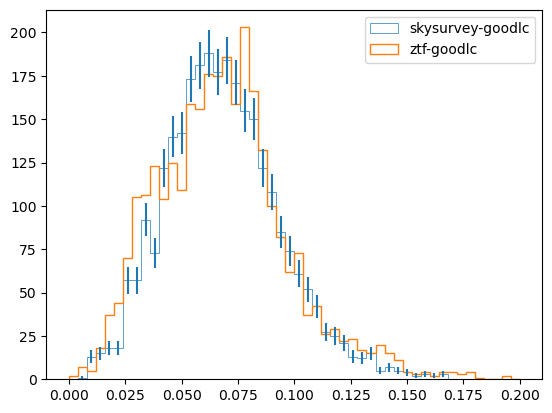

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

prop = dict(bins=50, range=[0, 0.2], histtype="step")

ax.hist(data_obs["z"], label="skysurvey-goodlc", linewidth=0.5, **prop)
ax.hist(datadr2_full["redshift"], label="ztf-goodlc", fill=False, **prop)


# added error bar
npoints, hbins = np.histogram(data_obs["z"], bins=50, range=[0, 0.2])
midbins = np.mean([hbins[:-1], hbins[1:]], axis=0)

ax.errorbar(midbins, npoints,  yerr=np.sqrt(npoints),
            marker="None", ls="None", ms=1,
           color="tab:blue")

ax.legend()